In [23]:
from ultralytics import YOLO

model = YOLO('runs/classify/train8/weights/best.pt')

In [24]:
metrics = model.val(data='data/dataset_externo.yaml', split='test', verbose=True)

Ultralytics 8.3.204 🚀 Python-3.10.18 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 5814MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 199.0±265.4 MB/s, size: 76.4 KB)
test: Scanning /home/lucas/Documentos/Lamia/ProjetoFinal/data/dataset_externo/test... 60 images, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 155.1Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 4/4 2.0it/s 2.0s0.4ss
                   all        0.7          1
Speed: 0.7ms preprocess, 6.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/lucas/Documentos/Lamia/ProjetoFinal/runs/classify/val22


In [25]:
print(metrics.top1)

0.699999988079071


In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
model = load_model("best_model.keras")

2025-11-21 11:50:21.983793: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 11:50:22.281656: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-21 11:50:23.531498: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1763736625.379217    4458 gpu_device.cc:2020] Created device /job:localhost/rep

In [2]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/dataset_externo/test/',
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 60 files belonging to 4 classes.


In [3]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Acurácia de teste: {test_acc:.4f}")
print(f"Perda de teste: {test_loss:.4f}")

2025-11-21 11:50:30.310725: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e6a300023e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-21 11:50:30.310739: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2025-11-21 11:50:30.331820: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-21 11:50:30.421274: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-21 11:50:33.366049: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1/2 ━━━━━━━━━━━━━━━━━━━━ 9s 10s/step - accuracy: 0.3750 - loss: 4.0119

I0000 00:00:1763736639.784061    4637 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-11-21 11:50:42.428801: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.91GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.4167 - loss: 3.1142
Acurácia de teste: 0.4167
Perda de teste: 3.1142


2025-11-21 11:50:53.342650: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Relatório de Classificação:

                      precision    recall  f1-score   support

            catarata       1.00      0.80      0.89        15
diabetic_retinopathy       0.00      0.00      0.00        15
            glaucoma       0.00      0.00      0.00        15
              normal       0.30      0.87      0.44        15

            accuracy                           0.42        60
           macro avg       0.32      0.42      0.33        60
        weighted avg       0.32      0.42      0.33        60



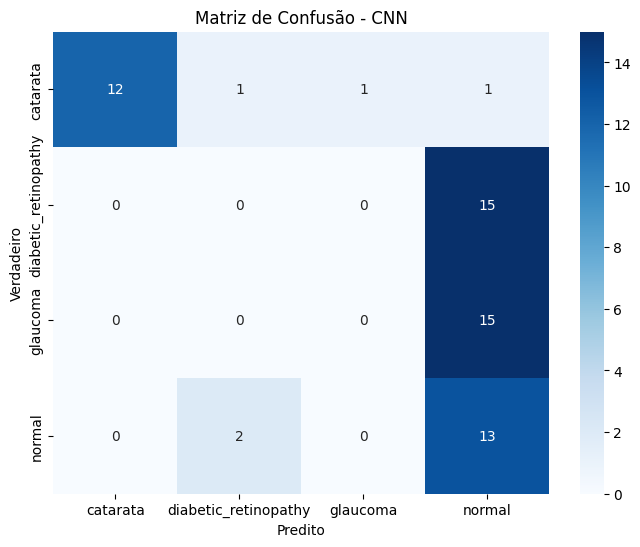

In [4]:
#Gera predições no conjunto de teste
class_names = test_ds.class_names
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

#Relatório de classificação
print("Relatório de Classificação:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

#Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão - CNN")
plt.savefig("confusion_matrix - dataset externo.png")
plt.show()